In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm 

In [3]:
df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])

In [4]:
actions = pd.read_csv("data/sp500_corporate_actions.csv")


actions["Date"] = pd.to_datetime(actions["Date"])

df["Date"] = pd.to_datetime(df["Date"])


df = df.merge(
    actions,
    on=["Date", "Ticker"],
    how="left"
)

df = df[
    (df["Stock Splits"].fillna(0) == 0) &
    (df["Dividends"].fillna(0) == 0)
]

In [5]:
# --- Full price data (with GSPC) ---
print(df.shape)
print(df.dtypes)
df.head()

(1715045, 11)
Date            datetime64[ns]
Ticker                  object
Open                   float64
High                   float64
Low                    float64
Close                  float64
Adj Close              float64
Volume                 float64
index                  float64
Dividends              float64
Stock Splits           float64
dtype: object


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,index,Dividends,Stock Splits
0,2010-01-04,A,22.453505,22.625179,22.267525,22.389128,19.810984,3815561.0,NaN,NaN,NaN
1,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,6.412382,493729600.0,NaN,NaN,NaN
2,2010-01-04,ABT,26.000362,26.177889,25.870815,26.129908,18.207748,10829095.0,NaN,NaN,NaN
3,2010-01-04,ACGL,7.978889,8.022222,7.972222,7.994444,7.601905,4813200.0,NaN,NaN,NaN
4,2010-01-04,ACN,41.520000,42.200001,41.500000,42.070000,31.227346,3650100.0,NaN,NaN,NaN


In [6]:
df_rf = pd.read_csv("data/DTB3.csv")

# rename for clarity
df_rf = df_rf.rename(columns={
    "observation_date": "date",
    "DTB3": "yield"
})

# convert date
df_rf['date'] = pd.to_datetime(df_rf['date'])

In [7]:
# --- Risk free rate ---
print(df_rf.shape)
print(df_rf.dtypes)
df_rf.head()

(4172, 2)
date     datetime64[ns]
yield           float64
dtype: object


,date,yield
0,2010-01-04,0.08
1,2010-01-05,0.07
2,2010-01-06,0.06
3,2010-01-07,0.05
4,2010-01-08,0.05


In [8]:
extremes = pd.read_csv("data/sp500_pct_extremes.csv")

In [9]:
print(extremes.shape)
print(extremes.dtypes)
extremes.head()

(1711, 17)
Date                    object
Ticker                  object
Open                   float64
High                   float64
Low                    float64
Close                  float64
Adj Close              float64
Volume                 float64
previous_adj_close     float64
arithmetic_return      float64
arithmetic_return_%    float64
log_return             float64
index                  float64
Dividends              float64
Stock Splits           float64
z_score_global         float64
extreme                   bool
dtype: object


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global,extreme
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.894868,True
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.091763,True
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.239995,True
3,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.948526,True
4,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,-43.452087,-0.570082,NaN,NaN,NaN,-29.406447,True


In [10]:
# -----------------------------
# 1. Market returns (GSPC from df)
# -----------------------------
market = (
    df[df["Ticker"] == "^GSPC"][["Date", "Adj Close"]]
    .sort_values("Date")
    .set_index("Date")
)
market["market_return"] = market["Adj Close"].pct_change()
market = market[["market_return"]].dropna()

print("Market returns:")
print(market.shape)
market.head()

Market returns:
(4096, 1)


,market_return
Date,
2010-01-05,0.003116
2010-01-06,0.000546
2010-01-07,0.004001
2010-01-08,0.002882
2010-01-11,0.001747


In [11]:
# -----------------------------
# 2. Risk-free rate (DTB3)
# -----------------------------
rf = (
    df_rf
    .sort_values("date")
    .set_index("date")
)

# DTB3 is annualized percentage (0.08 means 0.08%)
# Convert to daily decimal: divide by 100 to get decimal, then by 252 for daily
rf["rf_daily"] = (rf["yield"] / 100) / 252

rf = rf[["rf_daily"]].dropna()

print("Risk-free rate:")
print(rf.shape)
rf.head()

Risk-free rate:
(4000, 1)


,rf_daily
date,
2010-01-04,0.000003
2010-01-05,0.000003
2010-01-06,0.000002
2010-01-07,0.000002
2010-01-08,0.000002


In [12]:
# -----------------------------
# 3. Stock returns (excluding GSPC)
# -----------------------------
stocks = (
    df[df["Ticker"] != "^GSPC"][["Date", "Ticker", "Adj Close"]]
    .sort_values(["Ticker", "Date"])
)

stocks["stock_return"] = (
    stocks
    .groupby("Ticker")["Adj Close"]
    .pct_change()
)

stocks = stocks.dropna(subset=["stock_return"])

print("Stock returns:")
print(stocks.shape)
stocks.head()

Stock returns:
(1710525, 4)


,Date,Ticker,Adj Close,stock_return
424,2010-01-05,A,19.595783,-0.010863
848,2010-01-06,A,19.526167,-0.003553
1272,2010-01-07,A,19.500853,-0.001296
1696,2010-01-08,A,19.494513,-0.000325
2120,2010-01-11,A,19.507172,0.000649


In [13]:
# -----------------------------
# 4. Merge everything on date
# -----------------------------
capm_data = (
    stocks
    .merge(market, left_on="Date", right_index=True, how="inner")
    .merge(rf, left_on="Date", right_index=True, how="inner")
)

# Compute excess returns
capm_data["stock_excess"] = capm_data["stock_return"] - capm_data["rf_daily"]
capm_data["market_excess"] = capm_data["market_return"] - capm_data["rf_daily"]

print("\nFinal CAPM dataset:")
print(capm_data.shape)
print(capm_data[["Date", "Ticker", "stock_excess", "market_excess", "rf_daily"]].head())


Final CAPM dataset:
(1666959, 8)
           Date Ticker  stock_excess  market_excess  rf_daily
424  2010-01-05      A     -0.010865       0.003113  0.000003
848  2010-01-06      A     -0.003555       0.000543  0.000002
1272 2010-01-07      A     -0.001298       0.003999  0.000002
1696 2010-01-08      A     -0.000327       0.002880  0.000002
2120 2010-01-11      A      0.000648       0.001745  0.000002


In [14]:
# -----------------------------
# 5. CAPM regression — single stock
# -----------------------------
ticker = "AAPL"
stock_data = capm_data[capm_data["Ticker"] == ticker].copy()

X = sm.add_constant(stock_data["market_excess"])
y = stock_data["stock_excess"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           stock_excess   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     3485.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        13:12:21   Log-Likelihood:                 11494.
No. Observations:                3936   AIC:                        -2.298e+04
Df Residuals:                    3934   BIC:                        -2.297e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0005      0.000      2.629

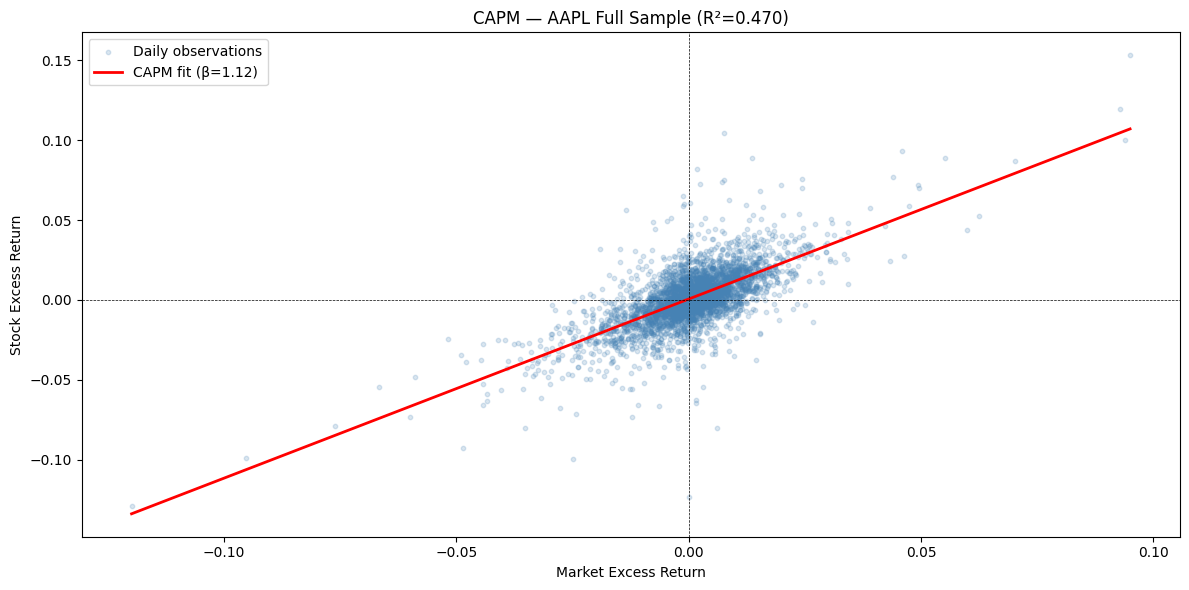

In [15]:
# -----------------------------
# 1. Scatter plot with regression line
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    stock_data["market_excess"],
    stock_data["stock_excess"],
    alpha=0.2, s=10, color="steelblue", label="Daily observations"
)

x_range = np.linspace(
    stock_data["market_excess"].min(),
    stock_data["market_excess"].max(), 100
)
y_hat = model.params["const"] + model.params["market_excess"] * x_range

ax.plot(x_range, y_hat, color="red", linewidth=2, label=f"CAPM fit (β={model.params['market_excess']:.2f})")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Market Excess Return")
ax.set_ylabel("Stock Excess Return")
ax.set_title(f"CAPM — {ticker} Full Sample (R²={model.rsquared:.3f})")
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# run the regression on all stock and summarize the results.

results = []

for ticker, group in tqdm(capm_data.groupby("Ticker")):
    # Need enough observations to run a regression
    if len(group) < 100:
        continue
    
    X = sm.add_constant(group["market_excess"])
    y = group["stock_excess"]
    
    try:
        model = sm.OLS(y, X).fit()
        results.append({
            "Ticker": ticker,
            "alpha": model.params["const"],
            "beta": model.params["market_excess"],
            "r2": model.rsquared,
            "p_alpha": model.pvalues["const"],
            "p_beta": model.pvalues["market_excess"],
            "n": len(group)
        })
    except Exception:
        continue

capm_full = pd.DataFrame(results)
print(f"Regressions run: {len(capm_full)}")
capm_full.head()

100%|██████████| 423/423 [00:02<00:00, 177.69it/s]

Regressions run: 423


,Ticker,alpha,beta,r2,p_alpha,p_beta,n
0,A,0.000134,1.157895,0.480006,0.523352,0.0,3936
1,AAPL,0.000547,1.121092,0.469760,0.008605,0.0,3936
2,ABT,0.000246,0.738777,0.348994,0.163096,0.0,3927
3,ACGL,0.000352,0.793867,0.334955,0.069585,0.0,3989
4,ACN,0.000133,1.021685,0.515069,0.442290,0.0,3949


In [17]:
summary = pd.DataFrame({
    "metric": ["alpha", "beta", "r2"],
    "mean":   [capm_full["alpha"].mean(),   capm_full["beta"].mean(),   capm_full["r2"].mean()],
    "median": [capm_full["alpha"].median(), capm_full["beta"].median(), capm_full["r2"].median()],
    "std":    [capm_full["alpha"].std(),     capm_full["beta"].std(),     capm_full["r2"].std()],
    "min":    [capm_full["alpha"].min(),     capm_full["beta"].min(),     capm_full["r2"].min()],
    "max":    [capm_full["alpha"].max(),     capm_full["beta"].max(),     capm_full["r2"].max()],
})

# What % of alphas are statistically significant?
pct_sig_alpha = (capm_full["p_alpha"] < 0.05).mean() * 100

print(summary.round(6))
print(f"\n% of stocks with significant alpha (p<0.05): {pct_sig_alpha:.1f}%")

  metric      mean    median       std       min       max
0  alpha  0.000201  0.000191  0.000237 -0.000457  0.001104
1   beta  0.980084  0.981246  0.283460  0.356161  1.694702
2     r2  0.337979  0.336831  0.118038  0.026121  0.642840

% of stocks with significant alpha (p<0.05): 9.2%


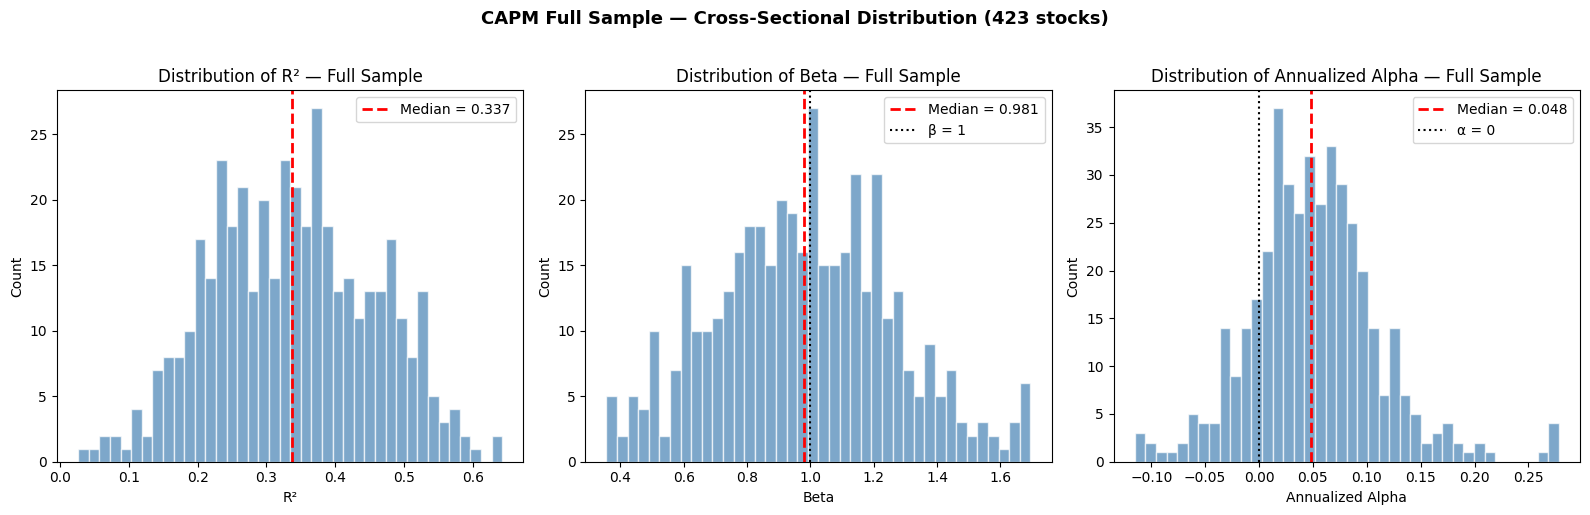

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# -----------------------------
# 1. Distribution of R²
# -----------------------------
axes[0].hist(capm_full["r2"], bins=40, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].axvline(capm_full["r2"].median(), color="red", linewidth=2, linestyle="--", label=f"Median = {capm_full['r2'].median():.3f}")
axes[0].set_title("Distribution of R² — Full Sample")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Count")
axes[0].legend()

# -----------------------------
# 2. Distribution of Beta
# -----------------------------
axes[1].hist(capm_full["beta"], bins=40, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].axvline(capm_full["beta"].median(), color="red", linewidth=2, linestyle="--", label=f"Median = {capm_full['beta'].median():.3f}")
axes[1].axvline(1.0, color="black", linewidth=1.5, linestyle=":", label="β = 1")
axes[1].set_title("Distribution of Beta — Full Sample")
axes[1].set_xlabel("Beta")
axes[1].set_ylabel("Count")
axes[1].legend()

# -----------------------------
# 3. Distribution of Alpha (annualized)
# -----------------------------
capm_full["alpha_annualized"] = capm_full["alpha"] * 252
axes[2].hist(capm_full["alpha_annualized"], bins=40, color="steelblue", alpha=0.7, edgecolor="white")
axes[2].axvline(capm_full["alpha_annualized"].median(), color="red", linewidth=2, linestyle="--", label=f"Median = {capm_full['alpha_annualized'].median():.3f}")
axes[2].axvline(0, color="black", linewidth=1.5, linestyle=":", label="α = 0")
axes[2].set_title("Distribution of Annualized Alpha — Full Sample")
axes[2].set_xlabel("Annualized Alpha")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("CAPM Full Sample — Cross-Sectional Distribution (423 stocks)", 
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Check the CAPM for the tails.

In [19]:
# Fix date type on extremes first
extremes["Date"] = pd.to_datetime(extremes["Date"])

# Merge to get market_excess and rf_daily for each extreme observation
capm_extremes = extremes.merge(
    capm_data[["Date", "Ticker", "stock_excess", "market_excess", "rf_daily"]],
    on=["Date", "Ticker"],
    how="inner"
)

# Split tails
capm_pos = capm_extremes[capm_extremes["stock_excess"] > 0].copy()
capm_neg = capm_extremes[capm_extremes["stock_excess"] < 0].copy()

print(f"Total extreme obs : {len(capm_extremes)}")
print(f"Positive tail     : {len(capm_pos)}")
print(f"Negative tail     : {len(capm_neg)}")
capm_extremes.head()

Total extreme obs : 1661
Positive tail     : 674
Negative tail     : 987


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global,extreme,stock_excess,market_excess,rf_daily
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.894868,True,-0.538660,-0.075982,0.000013
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.091763,True,-0.531610,0.007236,0.000208
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.239995,True,-0.523688,-0.005353,0.000095
3,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.948526,True,-0.440587,-0.000193,0.000150
4,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,-43.452087,-0.570082,NaN,NaN,NaN,-29.406447,True,-0.434522,0.003746,0.000001


First check on a stock that is in the extreme

In [22]:
# Find stocks with enough observations in each tail
obs_counts = pd.DataFrame({
    "full_tail": capm_extremes.groupby("Ticker").size(),
    "pos_tail":  capm_pos.groupby("Ticker").size(),
    "neg_tail":  capm_neg.groupby("Ticker").size(),
}).dropna()  # only stocks present in all three

# Filter to stocks with at least 10 obs in each
candidates = obs_counts[
    (obs_counts["full_tail"] >= 10) &
    (obs_counts["pos_tail"]  >= 5) &
    (obs_counts["neg_tail"]  >= 5)
].sort_values("full_tail", ascending=False)

print(candidates.head(10))

        full_tail  pos_tail  neg_tail
Ticker                               
SMCI           47      26.0      21.0
PCG            24       8.0      16.0
EXPE           23      11.0      12.0
AXON           22      13.0       9.0
APA            22      10.0      12.0
CCL            22       9.0      13.0
RCL            22      12.0      10.0
AMD            22      10.0      12.0
COHR           20      11.0       9.0
FSLR           20      12.0       8.0


In [ ]:
# let's try on SMCI first

In [23]:
ticker = "SMCI"

# Subset for this ticker
smci_full     = capm_data[capm_data["Ticker"] == ticker].copy()
smci_extremes = capm_extremes[capm_extremes["Ticker"] == ticker].copy()
smci_pos      = capm_pos[capm_pos["Ticker"] == ticker].copy()
smci_neg      = capm_neg[capm_neg["Ticker"] == ticker].copy()

# -----------------------------
# 1. Full sample
# -----------------------------
X = sm.add_constant(smci_full["market_excess"])
y = smci_full["stock_excess"]
model_full = sm.OLS(y, X).fit()
print("=" * 60)
print("SMCI — FULL SAMPLE")
print("=" * 60)
print(model_full.summary())

# -----------------------------
# 2. Full tail
# -----------------------------
X = sm.add_constant(smci_extremes["market_excess"])
y = smci_extremes["stock_excess"]
model_tail = sm.OLS(y, X).fit()
print("=" * 60)
print("SMCI — FULL TAIL")
print("=" * 60)
print(model_tail.summary())

# -----------------------------
# 3. Positive tail
# -----------------------------
X = sm.add_constant(smci_pos["market_excess"])
y = smci_pos["stock_excess"]
model_pos = sm.OLS(y, X).fit()
print("=" * 60)
print("SMCI — POSITIVE TAIL")
print("=" * 60)
print(model_pos.summary())

# -----------------------------
# 4. Negative tail
# -----------------------------
X = sm.add_constant(smci_neg["market_excess"])
y = smci_neg["stock_excess"]
model_neg = sm.OLS(y, X).fit()
print("=" * 60)
print("SMCI — NEGATIVE TAIL")
print("=" * 60)
print(model_neg.summary())

SMCI — FULL SAMPLE
                            OLS Regression Results                            
Dep. Variable:           stock_excess   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     788.5
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.74e-158
Time:                        13:30:20   Log-Likelihood:                 7668.0
No. Observations:                3991   AIC:                        -1.533e+04
Df Residuals:                    3989   BIC:                        -1.532e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0008   

In [20]:
def run_capm_loop(df, label, min_obs=5):
    results = []
    for ticker, group in df.groupby("Ticker"):
        if len(group) < min_obs:
            continue
        try:
            X = sm.add_constant(group["market_excess"])
            y = group["stock_excess"]
            model = sm.OLS(y, X).fit()
            results.append({
                "Ticker": ticker,
                "alpha": model.params["const"],
                "beta": model.params["market_excess"],
                "r2": model.rsquared,
                "p_alpha": model.pvalues["const"],
                "p_beta": model.pvalues["market_excess"],
                "n": len(group)
            })
        except Exception:
            continue
    df_out = pd.DataFrame(results)
    df_out["sample"] = label
    return df_out

capm_tail     = run_capm_loop(capm_extremes, "Full Tail")
capm_tail_pos = run_capm_loop(capm_pos,      "Positive Tail")
capm_tail_neg = run_capm_loop(capm_neg,      "Negative Tail")

print(f"Full tail regressions  : {len(capm_tail)}")
print(f"Positive tail          : {len(capm_tail_pos)}")
print(f"Negative tail          : {len(capm_tail_neg)}")

Full tail regressions  : 116
Positive tail          : 40
Negative tail          : 61


In [25]:
def summarize_capm(df, label):
    return {
        "sample": label,
        "n_stocks": len(df),
        "median_r2": df["r2"].median(),
        "mean_r2": df["r2"].mean(),
        "median_beta": df["beta"].median(),
        "median_alpha_ann": (df["alpha"] * 252).median(),
        "pct_sig_alpha": (df["p_alpha"] < 0.05).mean() * 100,
        "pct_sig_beta": (df["p_beta"] < 0.05).mean() * 100,
    }

comparison = pd.DataFrame([
    summarize_capm(capm_full,      "Full Sample"),
    summarize_capm(capm_tail_pos,  "Positive Tail"),
    summarize_capm(capm_tail_neg,  "Negative Tail"),
])

display(comparison.round(3))

,sample,n_stocks,median_r2,mean_r2,median_beta,median_alpha_ann,pct_sig_alpha,pct_sig_beta
0,Full Sample,423,0.337,0.338,0.981,0.048,9.220,100.000
1,Positive Tail,40,0.094,0.171,-0.065,50.902,100.000,7.500
2,Negative Tail,61,0.129,0.212,0.064,-43.149,95.082,11.475
